# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** William Keenan

**Date:** 9/9/26

In [1]:
# Your Phase 1 solution to the problem goes here.
#Q1: I am unable to upload the pictures to this assignment in Colab so I am uploading them as files in the github repo.

In [2]:
#Q2.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!git clone https://github.com/willhk10-uva/A02-eda-and-visualization
foreign_gifts = pd.read_csv('A02-eda-and-visualization/data/ForeignGifts_edu.csv')


foreign_gifts.head(10)

Cloning into 'A02-eda-and-visualization'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 33 (delta 9), reused 0 (delta 0), pack-reused 15 (from 1)
Receiving objects: 100% (33/33), 4.41 MiB | 22.15 MiB/s, done.
Resolving deltas: 100% (12/12), done.


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
5,6,105100,University of Alabama,Tuscaloosa,AL,43501,30231,Contract,KUWAIT,Kuwait-Embassy of the State
6,7,105100,University of Alabama,Tuscaloosa,AL,43507,30162,Contract,KUWAIT,Kuwait-Embassy of the State
7,8,105100,University of Alabama,Tuscaloosa,AL,43517,200,Monetary Gift,GERMANY,"Mercedes-Benz U.S. International, I"
8,9,105100,University of Alabama,Tuscaloosa,AL,43529,5136,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
9,10,105100,University of Alabama,Tuscaloosa,AL,43531,57049,Contract,JAPAN,Kansai Gaidai University (KGU)


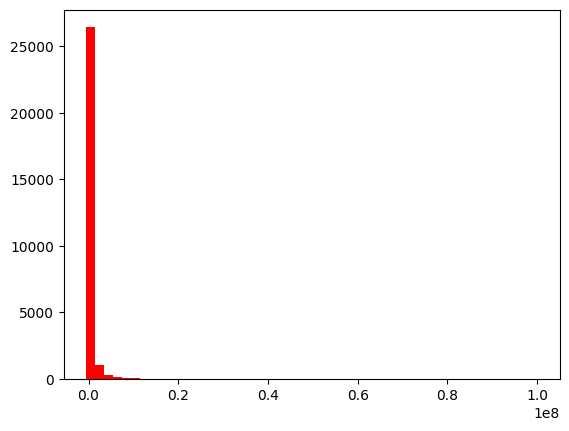

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


'We can see that there is an extremely large range of values, from -5.3E05 all the way to 1.0E8. This makes the\nscale of the histogram difficult to discern much information from, outside of a large clustering at around 0E8 to\n.02E8 and steep drop off after. The average is around 5.8E5.'

In [3]:
#Q2.2
df = foreign_gifts['Foreign Gift Amount']
plt.hist(df,bins=50,color="red")
plt.show()

print(df.describe())
'''We can see that there is an extremely large range of values, from -5.3E05 all the way to 1.0E8. This makes the
scale of the histogram difficult to discern much information from, outside of a large clustering at around 0E8 to
.02E8 and steep drop off after. The average is around 5.8E5.'''

In [4]:
#Q2.3
gt= foreign_gifts['Gift Type']
print(gt.value_counts())

print("\nProportion that are contract: ", 17274/gt.count())
print("Proportion that are monetary gifts:", 10936/gt.count())
print("Proportion that are real estate: ", 11/gt.count())




Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Proportion that are contract:  0.6120973742957372
Proportion that are monetary gifts: 0.3875128450444704
Proportion that are real estate:  0.00038978065979235324


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


'All of the different gift types have the same pattern'

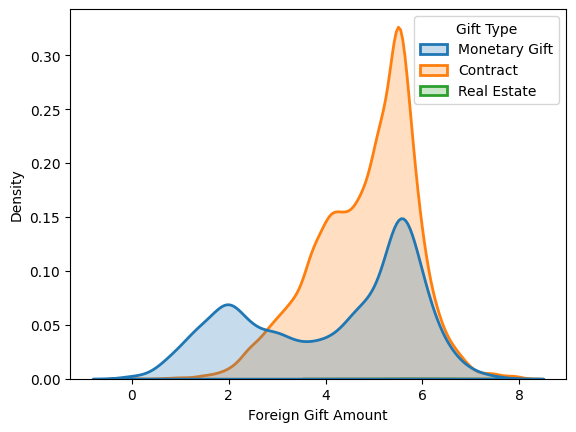

In [5]:
#Q2.4
ax = sns.kdeplot(x = np.log10(df), hue = gt, fill=True, color="blue", linewidth=2)

'''All of the different gift types have the same pattern'''

In [6]:
#Q2.5
var = foreign_gifts['Country of Giftor']
var1 = foreign_gifts["Foreign Gift Amount"]
top_count = var.value_counts().head(15)
top_value = var1.groupby(var).sum().nlargest(15)

summary = pd.concat({"num_gifts": top_count, "total_value": top_value}, axis=1)
print(summary)

                      num_gifts   total_value
Country of Giftor                            
ENGLAND                  3655.0  1.464907e+09
CHINA                    2461.0  1.237952e+09
CANADA                   2344.0  8.981607e+08
JAPAN                    1896.0  6.559548e+08
SWITZERLAND              1676.0  6.198994e+08
SAUDI ARABIA             1610.0  1.065206e+09
FRANCE                   1437.0  4.058394e+08
GERMANY                  1394.0  4.424756e+08
HONG KONG                1080.0  8.874025e+08
SOUTH KOREA               811.0           NaN
QATAR                     693.0  2.706241e+09
THE NETHERLANDS           512.0           NaN
KOREA                     452.0           NaN
INDIA                     434.0  5.395565e+08
TAIWAN                    381.0           NaN
BERMUDA                     NaN  8.995940e+08
UNITED ARAB EMIRATES        NaN  4.313964e+08
SINGAPORE                   NaN  4.011577e+08
AUSTRALIA                   NaN  2.484092e+08


In [7]:
#Q2.6

top_giftors = foreign_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(10)
display(top_giftors)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 27c0dbb492a5b481b5499bffb10bdaa6e3f831d1
- **AI tool and model used:** Gemini 3.1 Pro

### *Prompts used

1. Does this code effectively answer these questions: 2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings. 3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts? 4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns? 5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given? 6. Which giftors provide the most money, in total? #Q2.2 df = foreign_gifts['Foreign Gift Amount'] plt.hist(df,bins=50,color="red") plt.show() print(df.describe()) '''We can see that there is an extremely large range of values, from -5.3E05 all the way to 1.0E8. This makes the scale of the histogram difficult to discern much information from, outside of a large clustering at around 0E8 to .02E8 and steep drop off after. The average is around 5.8E5.''' #Q2.3 gt= foreign_gifts['Gift Type'] print(gt.value_counts()) print("\nProportion that are contract: ", 17274/gt.count()) print("Proportion that are monetary gifts:", 10936/gt.count()) print("Proportion that are real estate: ", 11/gt.count()) #Q2.4 ax = sns.kdeplot(x = np.log10(df), hue = gt, fill=True, color="blue", linewidth=2) '''All of the different gift types have the same pattern''' #Q2.5 var = foreign_gifts['Country of Giftor'] var1 = foreign_gifts["Foreign Gift Amount"] top_count = var.value_counts().head(15) top_value = var1.groupby(var).sum().nlargest(15) summary = pd.concat({"num_gifts": top_count, "total_value": top_value}, axis=1) print(summary) #Q2.6 top_giftors = foreign_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(10) display(top_giftors)

2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. For Q2.2 (Foreign Gift Amount histogram): Investigate and handle the negative values in the Foreign Gift Amount column (e.g., filter them out or transform them appropriately) before generating the histogram and descriptive statistics to ensure accurate representation and analysis.
2. For Q2.3 (Gift Type proportions): Modify the proportion calculations to use dynamic values obtained from gt.value_counts() instead of hardcoded numbers, making the code more robust to data changes.
3. For Q2.4 (Kernel density plot): Before applying np.log10 to df for the kernel density plot, filter out or appropriately handle any non-positive values in the Foreign Gift Amount column to avoid RuntimeWarning: invalid value encountered in log10 and produce a meaningful plot.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Negative values skew the histogram and may represent errors or refunds. Filtering them out provides a cleaner distribution. |
| 2 | Accept | Using dynamic values from `value_counts()` ensures the code remains robust and accurate even if the underlying dataset changes. |
| 3 | Accept | Logarithms are undefined for zero and negative numbers. Filtering for strictly positive values prevents the `RuntimeWarning` and allows the KDE plot to render correctly. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

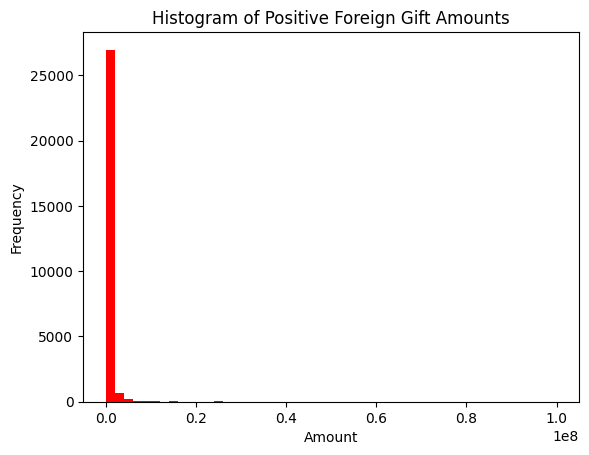

count    2.819700e+04
mean     5.887770e+05
std      3.223327e+06
min      1.000000e+00
25%      5.793000e+03
50%      9.509100e+04
75%      3.767520e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Proportion that are contract: 0.6120973742957372
Proportion that are monetary gifts: 0.3875128450444704
Proportion that are real estate: 0.00038978065979235324


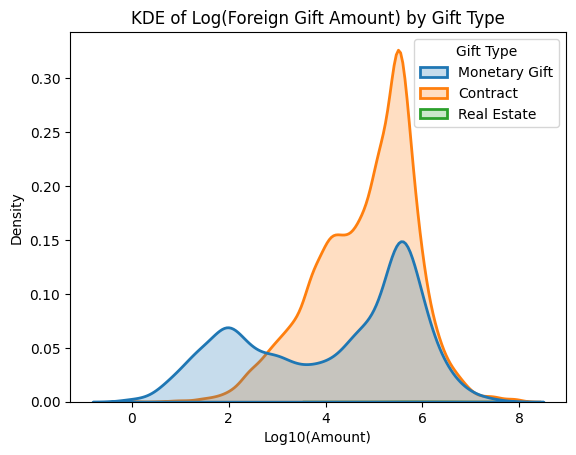

                      num_gifts   total_value
Country of Giftor                            
ENGLAND                  3655.0  1.464907e+09
CHINA                    2461.0  1.237952e+09
CANADA                   2344.0  8.981607e+08
JAPAN                    1896.0  6.559548e+08
SWITZERLAND              1676.0  6.198994e+08
SAUDI ARABIA             1610.0  1.065206e+09
FRANCE                   1437.0  4.058394e+08
GERMANY                  1394.0  4.424756e+08
HONG KONG                1080.0  8.874025e+08
SOUTH KOREA               811.0           NaN
QATAR                     693.0  2.706241e+09
THE NETHERLANDS           512.0           NaN
KOREA                     452.0           NaN
INDIA                     434.0  5.395565e+08
TAIWAN                    381.0           NaN
BERMUDA                     NaN  8.995940e+08
UNITED ARAB EMIRATES        NaN  4.313964e+08
SINGAPORE                   NaN  4.011577e+08
AUSTRALIA                   NaN  2.484092e+08


,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


In [9]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Q2.2 (Corrected) ---
# Filter out non-positive values to handle anomalies/errors
df_positive = foreign_gifts[foreign_gifts['Foreign Gift Amount'] > 0]['Foreign Gift Amount']

plt.hist(df_positive, bins=50, color="red")
plt.title("Histogram of Positive Foreign Gift Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

print(df_positive.describe())
'''By removing negative values (which might represent corrections or errors) and zeros, we get a clearer picture. The distribution is still highly right-skewed with a few extremely large gifts.'''

# --- Q2.3 (Corrected) ---
gt = foreign_gifts['Gift Type']
gt_counts = gt.value_counts()
print(gt_counts)

total_gifts = gt.count()
print("\nProportion that are contract:", gt_counts.get('Contract', 0) / total_gifts)
print("Proportion that are monetary gifts:", gt_counts.get('Monetary Gift', 0) / total_gifts)
print("Proportion that are real estate:", gt_counts.get('Real Estate', 0) / total_gifts)

# --- Q2.4 (Corrected) ---
# Using df_positive to avoid log10(<=0) issues
plt.figure()
ax = sns.kdeplot(x=np.log10(df_positive), hue=foreign_gifts.loc[df_positive.index, 'Gift Type'], fill=True, color="blue", linewidth=2)
plt.title("KDE of Log(Foreign Gift Amount) by Gift Type")
plt.xlabel("Log10(Amount)")
plt.show()

'''By taking the log of only the strictly positive gift amounts, we avoid the RuntimeWarning. The distributions of log-amounts appear somewhat similar across gift types, but contracts may have a slightly different peak than monetary gifts.'''

# --- Q2.5 (Unchanged) ---
var = foreign_gifts['Country of Giftor']
var1 = foreign_gifts["Foreign Gift Amount"]
top_count = var.value_counts().head(15)
top_value = var1.groupby(var).sum().nlargest(15)

summary = pd.concat({"num_gifts": top_count, "total_value": top_value}, axis=1)
print(summary)

# --- Q2.6 (Unchanged) ---
top_giftors = foreign_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(10)
display(top_giftors)


### *Reflection on AI assistance
In your own words without generative AI.

The main improvements came from three fixes. First, the negative values in Foreign Gift Amount - I had seen the minimum of roughly -537,000 in describe() and moved on without asking what a negative gift even means. Filtering to positive values made both the histogram and the summary statistics honest. Second, the RuntimeWarning on np.log10() was the same problem surfacing again, since the log of a non-positive number is undefined and those rows were silently dropping out of the density plot. Third, I replaced my hardcoded counts (17274, 10936, 11) with values pulled from value_counts(), so the proportions recompute if the data changes.

The AI's limitation was that it stayed at the level of mechanics. It flagged what would throw a warning or break, but it accepted my interpretation for Q2.4, that all gift types follow the same pattern, without questioning it. With eleven real estate observations, that curve isn't stable enough to compare against the other two, and the AI never said so.

Verification was thinner than I'd like to admit. I confirmed the code ran without warnings and that the plots looked reasonable, but "it executed successfully" is not the same as "it's correct." I should have checked how many rows the filter actually dropped and compared the filtered row count against the original.

What still concerns me is that I removed the negative values without understanding them. They may be corrections, refunds, or data entry errors, and each of those would call for different handling. I filtered them because they were inconvenient for taking a logarithm, which is a reason about my method rather than about the data.